<a href="https://colab.research.google.com/github/EsserMishelle/short-term-stock-forecast/blob/main/03_prophet_price_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Facebook Prophet
The objective of this project is to forecast the short-term closing price of NVIDIA (NVDA) stock using classical time-series models and compare their performance using information criteria and forecast accuracy.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

import seaborn as sns
import os
import time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define folder path within the drive
folder_path = '/content/drive/MyDrive/stocks'
os.makedirs(folder_path, exist_ok=True)

assets_folder_path = '/content/drive/MyDrive/stocks/assets'
os.makedirs(assets_folder_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load NVDA price and volume and merge them together

In [ ]:
# --- Load the price file ---
price_path = os.path.join(folder_path, 'stock_price_2021_2026.csv')

price_df = pd.read_csv(price_path,
    index_col='Date',
    parse_dates=True
)

df = price_df[[('NVDA_Close')]].copy()

# Rename column name
df.columns = ['nvda_close']

display(df.info())
print()

display(df.describe())
print()

display(df.head())
print()
display(df.tail())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1278 entries, 2021-01-04 to 2026-02-04
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nvda_close  1278 non-null   float64
dtypes: float64(1)
memory usage: 20.0 KB


None

,nvda_close
count,1278.000000
mean,69.329726
std,59.103824
min,11.212905
25%,19.515133
50%,42.327456
75%,121.585546
max,207.028473


,nvda_close
Date,
2021-01-04,13.076725
2021-01-05,13.367158
2021-01-06,12.579125
2021-01-07,13.306580
2021-01-08,13.239518


,nvda_close
Date,
2026-01-29,192.509995
2026-01-30,191.130005
2026-02-02,185.610001
2026-02-03,180.339996
2026-02-04,174.190002


### Initialize the Prophet model
Prophet already includes: trend and atomatic changepoints

* Stock prices don't have meaningful daily/weekly seasonality.
* Yearly effects sometimes show up in tax cycles and earning cadence

In [ ]:
# Create Prophet dataset

split_date = pd.to_datetime('2025-02-03')

prophet_nvda = df['nvda_close'].reset_index()
prophet_nvda.columns = ['ds', 'y']

# ensure ds is datetime
prophet_nvda['ds'] = pd.to_datetime(prophet_nvda['ds'])
# prophet_nvda.info()

prophet_train = prophet_nvda[prophet_nvda['ds'] < split_date]
prophet_test  = prophet_nvda[prophet_nvda['ds'] >= split_date]

print("Train max:", prophet_train['ds'].max())
print("Test min :", prophet_test['ds'].min())

Train max: 2025-01-31 00:00:00
Test min : 2025-02-03 00:00:00


In [ ]:
# Training
# Trained only on TRAIN window

prophet_model = Prophet(yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False)

prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
prophet_model.add_seasonality(name='quarterly', period=91.25, fourier_order=5)

prophet_model.fit(prophet_train)

### Transform the dataset to Facebook Prophet required format.

In [ ]:
test_length = len(prophet_test)
FUTURE_DAYS = 30

periods = test_length + FUTURE_DAYS

# Create future dates
prophet_future = prophet_model.make_future_dataframe(periods=periods, freq='B') #'B' for business days, 120 days

# Predict and generate forecast
prophet_forecast = prophet_model.predict(prophet_future)

display(prophet_forecast.tail())
print()
display(prophet_forecast.head())

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,monthly,...,quarterly,quarterly_lower,quarterly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1303,2026-02-26,228.546983,194.375876,267.239307,192.877647,264.117495,1.759445,1.759445,1.759445,-2.315248,...,-48.397610,-48.397610,-48.397610,52.472303,52.472303,52.472303,0.0,0.0,0.0,230.306428
1304,2026-02-27,228.745117,194.550846,266.819723,193.054175,264.474740,1.340857,1.340857,1.340857,-2.434754,...,-44.557832,-44.557832,-44.557832,48.333443,48.333443,48.333443,0.0,0.0,0.0,230.085974
1305,2026-03-02,229.339520,193.207052,266.974003,193.508828,265.132778,0.048439,0.048439,0.048439,-2.160566,...,-33.137848,-33.137848,-33.137848,35.346853,35.346853,35.346853,0.0,0.0,0.0,229.387959
1306,2026-03-03,229.537655,192.711426,267.889280,193.586745,265.392580,0.030218,0.030218,0.030218,-1.534614,...,-29.443381,-29.443381,-29.443381,31.008213,31.008213,31.008213,0.0,0.0,0.0,229.567873
1307,2026-03-04,229.735789,193.207391,268.088549,193.609628,265.898915,0.137104,0.137104,0.137104,-0.782220,...,-25.826852,-25.826852,-25.826852,26.746176,26.746176,26.746176,0.0,0.0,0.0,229.872893


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,monthly,...,quarterly,quarterly_lower,quarterly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-01-04,17.444711,6.108105,17.195570,17.444711,17.444711,-5.978846,-5.978846,-5.978846,2.378171,...,47.155034,47.155034,47.155034,-55.512051,-55.512051,-55.512051,0.0,0.0,0.0,11.465865
1,2021-01-05,17.418521,5.403224,17.157525,17.418521,17.418521,-6.074279,-6.074279,-6.074279,2.617103,...,49.252925,49.252925,49.252925,-57.944307,-57.944307,-57.944307,0.0,0.0,0.0,11.344242
2,2021-01-06,17.392331,5.475797,16.715072,17.392331,17.392331,-6.282252,-6.282252,-6.282252,2.668740,...,51.335415,51.335415,51.335415,-60.286407,-60.286407,-60.286407,0.0,0.0,0.0,11.110079
3,2021-01-07,17.366141,5.520231,16.945561,17.366141,17.366141,-6.498543,-6.498543,-6.498543,2.624594,...,53.373313,53.373313,53.373313,-62.496449,-62.496449,-62.496449,0.0,0.0,0.0,10.867598
4,2021-01-08,17.339950,4.830430,16.029826,17.339950,17.339950,-6.618808,-6.618808,-6.618808,2.577961,...,55.333868,55.333868,55.333868,-64.530637,-64.530637,-64.530637,0.0,0.0,0.0,10.721143


In [ ]:
prophet_eval = prophet_nvda.merge(
    prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds',
    how='left',
)

Align prophet_train_eval and prophet_test_eval row-by-row

In [ ]:
train_mask = prophet_eval['ds'] < prophet_test['ds'].min()
test_mask  = (
    (prophet_eval['ds'] >= prophet_test['ds'].min()) &
    (prophet_eval['ds'] <= prophet_test['ds'].max())
)
prophet_train_eval = prophet_eval[train_mask]
prophet_test_eval  = prophet_eval[test_mask]

In [ ]:
train_clean = prophet_train_eval.dropna(subset=['yhat'])
test_clean  = prophet_test_eval.dropna(subset=['yhat'])

print("NaNs in train yhat:", prophet_train_eval['yhat'].isna().sum())
print("NaNs in test yhat:", prophet_test_eval['yhat'].isna().sum())
print("Train rows used:", len(train_clean), " / ", len(prophet_train_eval))
print("Test rows used:", len(test_clean), " / ", len(prophet_test_eval))

NaNs in train yhat: 0
NaNs in test yhat: 0
Train rows used: 1025  /  1025
Test rows used: 253  /  253


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(actual, pred):
  actual = np.array(actual)
  pred = np.array(pred)
  return np.mean(np.abs((actual - pred) / actual)) * 100

mae_train = mean_absolute_error(train_clean['y'], train_clean['yhat'])
mae_test  = mean_absolute_error(test_clean['y'], test_clean['yhat'])

rmse_train = np.sqrt(mean_squared_error(train_clean['y'], train_clean['yhat']))
rmse_test  = np.sqrt(mean_squared_error(test_clean['y'], test_clean['yhat']))

mape_train = mape(train_clean['y'], train_clean['yhat'])
mape_test  = mape(test_clean['y'], test_clean['yhat'])

prophet_metrics = pd.DataFrame({

    'Model': ['Prophet'],
    'Train_MAE': [mae_train],
    'Test_MAE': [mae_test],
    'Train_RMSE': [rmse_train],
    'Test_RMSE': [rmse_test],
    'Train_MAPE': [mape_train],
    'Test_MAPE': [mape_test]
})

display(prophet_metrics)

,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_MAPE,Test_MAPE
0,Prophet,3.250777,29.51168,4.423377,33.094327,9.423805,21.219354


In [ ]:
file_path = os.path.join(folder_path, 'prophet_results.csv')
prophet_metrics.to_csv(file_path, index=False)

print("Saved to:", file_path)

Saved to: /content/drive/MyDrive/stocks/prophet_results.csv


#### The Prophet metric has a significant gap between train rmse ≈ 4.42 and test rmse ≈ 33.04. This means Prophet is underfitting the volatility, regimes or market shocks.

### Training, Testing and Future 30 Days Forecast Charts

The below charts show Prophet trains on historical NVDA prices, evaluates on a 90-day test window, and generates a 30-business-day forward forecast with 95% confidence intervals.

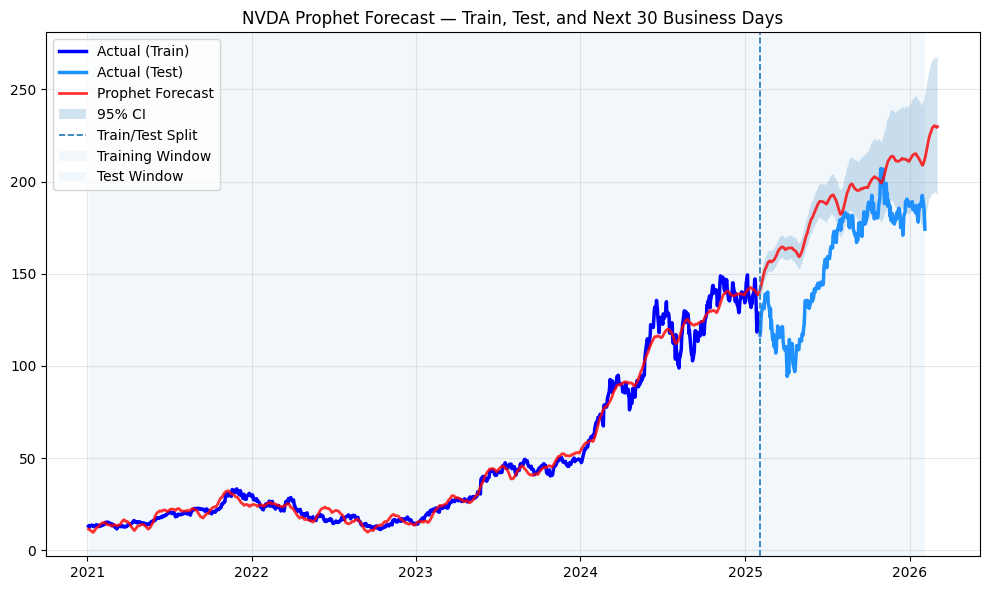

Test window start: 2025-02-03 00:00:00
Test window end:   2026-02-04 00:00:00
Forecast end:      2026-03-04 00:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

split_date = pd.to_datetime('2025-02-03')
train_end  = prophet_train['ds'].max()

plt.figure(figsize=(10,6))

# Actuals
plt.plot(prophet_train['ds'], prophet_train['y'], label='Actual (Train)', linewidth=2.5, color='blue')
plt.plot(prophet_test['ds'],  prophet_test['y'],  label='Actual (Test)',  linewidth=2.5, color='dodgerblue')

# Forecast
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast', linewidth=2, alpha=0.8, color='red')

# Shade uncertainty only AFTER training end (true "future" for the fitted model)
forecast_future = prophet_forecast[prophet_forecast['ds'] > train_end]
plt.fill_between(
    forecast_future['ds'],
    forecast_future['yhat_lower'],
    forecast_future['yhat_upper'],
    alpha=0.2,
    label='95% CI'
)

# Train/Test split marker (fixed)
plt.axvline(split_date, linestyle='--', linewidth=1.2, label='Train/Test Split')

# Window shading (use fixed split)
plt.axvspan(prophet_train['ds'].min(), split_date, alpha=0.06, label='Training Window')
plt.axvspan(split_date, prophet_test['ds'].max(), alpha=0.06, label='Test Window')

plt.title('NVDA Prophet Forecast — Train, Test, and Next 30 Business Days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(assets_folder_path, 'prophet_next30Day_nvda_forecast.jpg'))
plt.show()
print("Test window start:", prophet_test['ds'].min())
print("Test window end:  ", prophet_test['ds'].max())
print("Forecast end:     ", prophet_forecast['ds'].max())


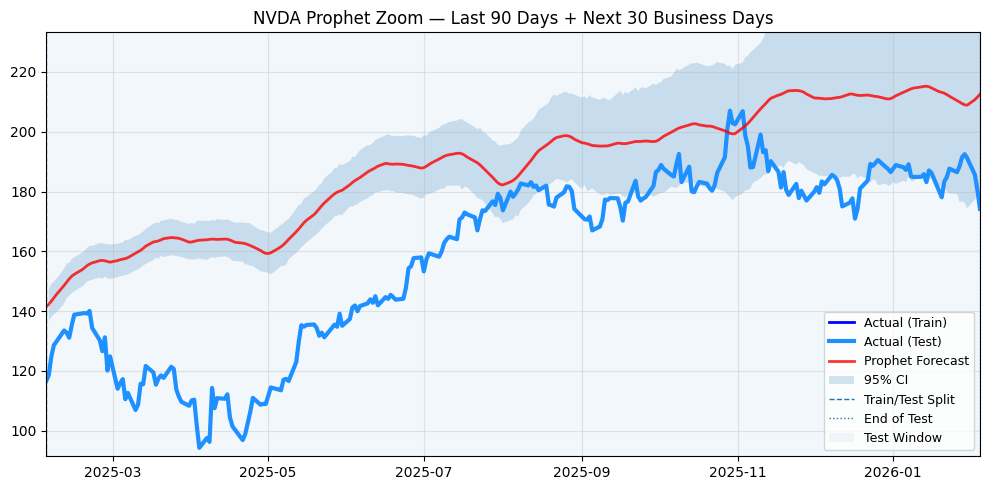

Zoom start: 2025-02-03 00:00:00
Test end: 2026-02-04 00:00:00
Forecast end: 2026-03-04 00:00:00


In [ ]:
# Zoom Version of the Prophet Forecast Chart
plt.figure(figsize=(10,5))

test_end = prophet_test['ds'].max()
forecast_end = prophet_forecast['ds'].max()

# Actual data

plt.plot(prophet_train['ds'], prophet_train['y'],
         label='Actual (Train)', linewidth=2, color='blue' )

plt.plot(prophet_test['ds'], prophet_test['y'],
         label='Actual (Test)', linewidth=3, color='dodgerblue')

plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'],
         label='Prophet Forecast', linewidth=2, alpha=0.8, color='red')

future_only = prophet_forecast[prophet_forecast['ds'] > split_date]
plt.fill_between(
    future_only['ds'],
    future_only['yhat_lower'],
    future_only['yhat_upper'],
    alpha=0.2, label='95% CI'
)

plt.axvline(split_date, linestyle='--', linewidth=1, label='Train/Test Split')
plt.axvline(test_end, linestyle=':', linewidth=1, label='End of Test')

# This is the zoom part
zoom_start = prophet_test['ds'].min()            # start of last 90 days
zoom_end   = prophet_test['ds'].max()            # end of 30-day forecast
# zoom_end   = forecast_end
plt.xlim(zoom_start, zoom_end)

# tighten y-axis so the zoom is readable
y_min = prophet_test['y'].min() * 0.97
y_max = prophet_test['y'].max() * 1.03
plt.ylim(y_min, y_max+20)

plt.axvspan(split_date, prophet_test['ds'].max(), alpha=0.06, label='Test Window')

# Labels
plt.title('NVDA Prophet Zoom — Last 90 Days + Next 30 Business Days')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(assets_folder_path, 'prophet_next30Day_nvda_forecast_zoom.jpg'))
plt.show()

print("Zoom start:", zoom_start)
print("Test end:", test_end)
print("Forecast end:", forecast_end)


#### Prophet Summary:

Prophet captures the long-term upward smooth trend in NVDA prices but struggles to fully capture short-term volatility during the test window. Forecast accuracy deteriorates during periods of rapid market movement, suggesting that additive seasonal models may have limited ability to model the complex dynamics of equity price movements.